# 04 — Telco: Trees and Random Forest

**Objective:** Keep the experiment fixed and observe what changes when we replace Logistic Regression with tree-based models.

Same data. Same preprocessing. Same folds. Same metric. Only the model changes.

## Rebuild the Session 2 experiment

We repeat the setup so this notebook can run on its own. Parsing `TotalCharges` learns nothing from other customers. Imputation, scaling and encoding must be learned inside each training fold, as in notebook 03. Observe that the dataset and column groups stay unchanged.

In [1]:
# Use Path so the repository-relative data location works across operating systems.
from pathlib import Path

# Import pandas to load the CSV, parse values, and display result tables.
import pandas as pd
# Route named column groups through different preprocessing branches.
from sklearn.compose import ColumnTransformer
# Learn a replacement value for missing numeric observations.
from sklearn.impute import SimpleImputer
# Use the linear classifier taught in Session 2.
from sklearn.linear_model import LogisticRegression
# Import the holdout split, stratified folds, and cross-validation runner.
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
# Chain learned transformations and the classifier inside one training boundary.
from sklearn.pipeline import Pipeline
# Scale numeric columns and encode categorical columns without ordinal assumptions.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Point from the notebooks folder to the course CSV stored in the repository.
data_path = Path("../data/telco.csv")
# Load one row per customer into a DataFrame.
df = pd.read_csv(data_path)

# Parse each value independently; this deterministic step learns no population statistic.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],  # Start from the original text column.
    errors="coerce"  # Convert whitespace-only values to NaN, never to zero.
)

## Define predictors and target

`Churn` is the outcome we want to predict, so it cannot also be an input. `customerID` identifies a customer but is not evidence that the customer will churn.

In [2]:
# Remove the outcome and identifier so neither can become a model input.
X = df.drop(columns=["Churn", "customerID"])
# Encode observed churn as 1 and non-churn as 0 for binary classification.
y = df["Churn"].eq("Yes").astype(int)

# Confirm the number of customer rows and usable predictor columns.
print(f"Predictor shape: {X.shape}")
# Report target prevalence because it motivates stratification and Average Precision.
print(f"Churn rate: {y.mean():.1%}")

Predictor shape: (7043, 19)
Churn rate: 26.5%


## Route numeric and categorical columns

For this course example, `tenure`, `MonthlyCharges`, and `TotalCharges` are numeric. Every other predictor is treated as categorical. In particular, `SeniorCitizen` is stored as 0/1 but represents a category rather than a measured quantity.

In [3]:
# List the measured quantities that need numeric imputation and scaling.
numeric_columns = [
    "tenure",  # Duration measured in months.
    "MonthlyCharges",  # Current monthly amount charged.
    "TotalCharges"  # Accumulated amount, including the parsed missing values.
]

# Route every remaining predictor, including SeniorCitizen, as a category.
categorical_columns = [
    column for column in X.columns  # Inspect every available predictor name.
    if column not in numeric_columns  # Exclude the three numeric columns listed above.
]

# Make the manual routing visible before any preprocessing is fitted.
print("Numeric:", numeric_columns)
# Confirm which fields will be converted to one-hot indicator columns.
print("Categorical:", categorical_columns)

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Define preprocessing

The numeric branch follows this sequence:

`missing value → median imputation → standard scaling`

The median, mean, and standard deviation are learned from training rows. Validation rows may be transformed with those learned values but must never change them.

The categorical branch uses one-hot encoding. Categories become indicator columns without introducing an artificial numeric order. `handle_unknown="ignore"` lets the encoder process a category not seen during a particular training fold without refitting on validation data.

In [4]:
# Define an unfitted numeric sequence; its statistics will be learned inside each fold.
numeric_preprocessing = Pipeline([
    ("impute", SimpleImputer(strategy="median")),  # Learn training medians for NaN values.
    ("scale", StandardScaler())  # Learn training means and standard deviations.
])

# Send each named column group through its own transformation branch.
preprocess = ColumnTransformer([
    ("num", numeric_preprocessing, numeric_columns),  # Impute and scale numeric fields.
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),  # Encode categories and tolerate unseen ones.
        categorical_columns  # Apply the encoder only to the categorical fields.
    )
], remainder="drop")  # Drop any predictor not explicitly assigned to a branch.

## Lock the final test set

We reserve 20% of the rows before cross-validation. The locked set does not participate in validation, model selection, or preprocessing decisions, and it is not scored in this notebook.

In [5]:
# Reserve the final test boundary before cross-validation or learned preprocessing.
X_dev, X_locked, y_dev, y_locked = train_test_split(
    X,  # Split the raw predictor rows before fitting any transformer.
    y,  # Apply the identical row split to the target.
    test_size=0.20,  # Lock 20% away for a future final evaluation.
    stratify=y,  # Preserve approximately the same churn share in both subsets.
    random_state=42  # Make the holdout membership reproducible.
)

# Report only subset sizes; do not inspect or score the locked labels.
split_summary = pd.Series({
    "Development rows": len(X_dev),  # These rows may enter cross-validation.
    "Locked test rows": len(X_locked),  # These rows remain untouched here.
})
# Display the boundary so students can verify the 80/20 split.
split_summary

Development rows    5634
Locked test rows    1409
dtype: int64

## Five-fold stratified cross-validation

A fold is one partition of the development data. Five folds create five rounds: each development row is used for validation once and for training in the other four rounds. The five fitted Pipelines are temporary; the result we inspect is the five validation scores. Stratification keeps approximately the same churn proportion in every validation fold.

In [6]:
# Define the five reproducible train/validation partitions of development data.
cv = StratifiedKFold(
    n_splits=5,  # Create five rounds, with each row validating exactly once.
    shuffle=True,  # Randomize row order before assigning folds.
    random_state=42  # Reproduce the same shuffled fold membership.
)

In [7]:
# Save the exact five partitions once, then reuse them for every model.
folds = list(cv.split(X_dev, y_dev))

**The locked test will not be used to choose between models.** All scores below use Development rows only.

Same data → Same preprocessing → Same folds → Same metric → Different model.

Change one thing. Observe what happens.

In [8]:
# Draw small, readable figures.
import matplotlib.pyplot as plt
# Combine many different decision trees.
from sklearn.ensemble import RandomForestClassifier
# Compute AP on training rows for the overfitting demonstration.
from sklearn.metrics import average_precision_score
# Fit individual trees and draw the deliberately small one.
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Logistic Regression reference

Rebuild the Session 2 reference before changing the classifier. Compare the five AP scores and their mean with notebook 03; they should match in the same environment.

In [9]:
# Keep the same preprocessing and replace only the classifier.
logistic_model = Pipeline([
    ("preprocess", preprocess),  # Learn transformations inside each training fold.
    ("classifier", LogisticRegression(C=1, solver="lbfgs", max_iter=2000)),  # Use this fixed classroom configuration.
])
# Compute Average Precision on the same five Development validation folds.
logistic_scores = cross_val_score(logistic_model, X_dev, y_dev, cv=folds, scoring="average_precision")
# Display every fold so the mean does not hide variation.
print(pd.Series(logistic_scores, index=range(1, 6), name="Fold AP"))
# Summarize validation performance and sample fold variation.
print(f"Mean AP: {logistic_scores.mean():.3f}; Fold std: {logistic_scores.std(ddof=1):.3f}")

1    0.643523
2    0.635589
3    0.685717
4    0.678189
5    0.664162
Name: Fold AP, dtype: float64
Mean AP: 0.661; Fold std: 0.022


## A deliberately small Decision Tree

A tree asks successive questions about customer fields. We limit it to depth 2 so we can read those questions. This is a teaching choice, not a search for the best depth. Observe how its validation AP compares with the linear reference.

In [10]:
# Keep the same preprocessing and replace only the classifier.
simple_tree_model = Pipeline([
    ("preprocess", preprocess),  # Learn transformations inside each training fold.
    ("classifier", DecisionTreeClassifier(max_depth=2, random_state=42)),  # Use this fixed classroom configuration.
])
# Compute Average Precision on the same five Development validation folds.
simple_tree_scores = cross_val_score(simple_tree_model, X_dev, y_dev, cv=folds, scoring="average_precision")
# Display every fold so the mean does not hide variation.
print(pd.Series(simple_tree_scores, index=range(1, 6), name="Fold AP"))
# Summarize validation performance and sample fold variation.
print(f"Mean AP: {simple_tree_scores.mean():.3f}; Fold std: {simple_tree_scores.std(ddof=1):.3f}")

1    0.499073
2    0.473907
3    0.485970
4    0.499375
5    0.511434
Name: Fold AP, dtype: float64
Mean AP: 0.494; Fold std: 0.014


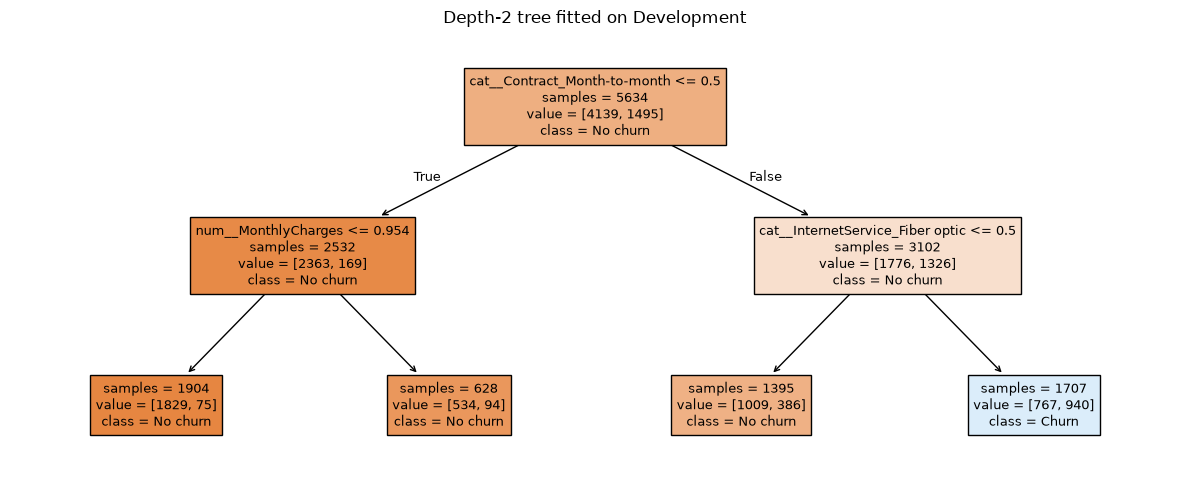

In [11]:
# Fit on Development only to illustrate the questions learned by this small tree.
simple_tree_model.fit(X_dev, y_dev);
# Retrieve the readable names of the transformed input columns.
feature_names = simple_tree_model.named_steps["preprocess"].get_feature_names_out()
# Create a compact figure with enough room for seven nodes.
plt.figure(figsize=(12, 5))
# Hide the impurity statistic and show the split questions and class counts.
plot_tree(simple_tree_model.named_steps["classifier"], feature_names=feature_names,
          class_names=["No churn", "Churn"], impurity=False, filled=True, fontsize=9);
# Label the illustration as a Development fit, separate from CV scores.
plt.title("Depth-2 tree fitted on Development")
# Reduce unused margins around the tree.
plt.tight_layout()
# Display the figure without displaying estimator objects.
plt.show()

Numeric thresholds refer to scaled values; one-hot thresholds separate category membership. The class counts describe training customers in each node. This picture illustrates a Development fit; the AP above still comes from unseen validation rows.

## Let the tree grow

Remove the depth limit while preserving the experiment. Compare training AP with validation AP and inspect the depth reached. **More flexibility does not automatically mean better generalisation.**

In [12]:
# Keep the same preprocessing and replace only the classifier.
full_tree_model = Pipeline([
    ("preprocess", preprocess),  # Learn transformations inside each training fold.
    ("classifier", DecisionTreeClassifier(random_state=42)),  # Use this fixed classroom configuration.
])
# Compute Average Precision on the same five Development validation folds.
full_tree_scores = cross_val_score(full_tree_model, X_dev, y_dev, cv=folds, scoring="average_precision")
# Display every fold so the mean does not hide variation.
print(pd.Series(full_tree_scores, index=range(1, 6), name="Fold AP"))
# Summarize validation performance and sample fold variation.
print(f"Mean AP: {full_tree_scores.mean():.3f}; Fold std: {full_tree_scores.std(ddof=1):.3f}")

1    0.373422
2    0.371038
3    0.387422
4    0.381655
5    0.376650
Name: Fold AP, dtype: float64
Mean AP: 0.378; Fold std: 0.007


In [13]:
# Fit the unrestricted tree on Development to inspect what it can memorize.
full_tree_model.fit(X_dev, y_dev);
# Obtain churn scores for the same rows used to fit this illustration.
training_scores = full_tree_model.predict_proba(X_dev)[:, 1]
# Show the actual number of successive splits in the fitted tree.
print("Tree depth:", full_tree_model.named_steps["classifier"].get_depth())
# Training AP is descriptive and is not evidence of performance on new customers.
print(f"Training AP (all Development): {average_precision_score(y_dev, training_scores):.3f}")
# Use held-out validation folds for the generalisation comparison.
print(f"Validation AP (CV mean): {full_tree_scores.mean():.3f}")

Tree depth: 22
Training AP (all Development): 1.000
Validation AP (CV mean): 0.378


The training and validation summaries use different training sizes: the illustration fits all Development rows, whereas each CV model fits four folds. Look for a large training–validation gap, rather than treating training AP as a selection score.

## Random Forest

Each tree sees a random sample of customers, drawn with replacement. Trees are different, and the forest combines their predictions. One tree can be unstable, while combining many trees can be more robust. Random Forest also randomizes candidate features at splits.

We use 100 trees and a fixed seed, without tuning. Observe whether combining trees improves held-out AP.

In [14]:
# Keep the same preprocessing and replace only the classifier.
forest_model = Pipeline([
    ("preprocess", preprocess),  # Learn transformations inside each training fold.
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)),  # Use this fixed classroom configuration.
])
# Compute Average Precision on the same five Development validation folds.
forest_scores = cross_val_score(forest_model, X_dev, y_dev, cv=folds, scoring="average_precision")
# Display every fold so the mean does not hide variation.
print(pd.Series(forest_scores, index=range(1, 6), name="Fold AP"))
# Summarize validation performance and sample fold variation.
print(f"Mean AP: {forest_scores.mean():.3f}; Fold std: {forest_scores.std(ddof=1):.3f}")

1    0.562028
2    0.595573
3    0.633772
4    0.612044
5    0.640777
Name: Fold AP, dtype: float64
Mean AP: 0.609; Fold std: 0.032


## Compare the evidence

The table uses only the same five validation folds. Mean AP summarizes ranking performance; fold standard deviation describes variation across these particular folds.

In [15]:
# Collect the four sets of validation scores in teaching order.
comparison_scores = {
    "Logistic Regression": logistic_scores,  # Keep the linear reference visible.
    "Simple Decision Tree": simple_tree_scores,  # Include the readable depth-2 tree.
    "Full Decision Tree": full_tree_scores,  # Include the unrestricted tree.
    "Random Forest": forest_scores,  # Include the combined trees.
}
# Build one compact row per model using sample standard deviation.
comparison = pd.DataFrame({name: {"Mean AP": scores.mean(), "Fold std": scores.std(ddof=1)}
                           for name, scores in comparison_scores.items()}).T
# Display rounded values while retaining full precision in the table.
comparison.round(3)

,Mean AP,Fold std
Logistic Regression,0.661,0.022
Simple Decision Tree,0.494,0.014
Full Decision Tree,0.378,0.007
Random Forest,0.609,0.032


Read the actual ordering in the table: does added complexity improve AP here? Does the unrestricted tree justify its flexibility?

A more sophisticated model does not automatically produce a better result. Complexity is a cost. It only makes sense if the evidence justifies it. The locked test remains available for a later final evaluation.